In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
sns.set_style("whitegrid")

print("✅ Библиотеки импортированы!")

df = pd.read_csv('../data/tickets.csv')

print("=" * 60)
print("📊 РАЗМЕР ДАТАСЕТА")
print("=" * 60)
print(f"Строк: {df.shape[0]}")
print(f"Колонок: {df.shape[1]}")

print("\n" + "=" * 60)
print("🔍 ИНФОРМАЦИЯ О КОЛОНКАХ")
print("=" * 60)
df.info()

print("\n" + "=" * 60)
print("⚠️ ПРОПУСКИ В ДАННЫХ")
print("=" * 60)
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0])

✅ Библиотеки импортированы!
📊 РАЗМЕР ДАТАСЕТА
Строк: 8469
Колонок: 17

🔍 ИНФОРМАЦИЯ О КОЛОНКАХ
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8469 entries, 0 to 8468
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Ticket ID                     8469 non-null   int64  
 1   Customer Name                 8469 non-null   object 
 2   Customer Email                8469 non-null   object 
 3   Customer Age                  8469 non-null   int64  
 4   Customer Gender               8469 non-null   object 
 5   Product Purchased             8469 non-null   object 
 6   Date of Purchase              8469 non-null   object 
 7   Ticket Type                   8469 non-null   object 
 8   Ticket Subject                8469 non-null   object 
 9   Ticket Description            8469 non-null   object 
 10  Ticket Status                 8469 non-null   object 
 11  Resolution                

📊 РАСПРЕДЕЛЕНИЕ ТИКЕТОВ ПО СТАТУСАМ
Ticket Status
Pending Customer Response    2881
Open                         2819
Closed                       2769
Name: count, dtype: int64

Процентное соотношение:
Ticket Status
Pending Customer Response    34.02
Open                         33.29
Closed                       32.70
Name: count, dtype: float64

🎯 РАСПРЕДЕЛЕНИЕ ПО ПРИОРИТЕТАМ
Ticket Priority
Medium      2192
Critical    2129
High        2085
Low         2063
Name: count, dtype: int64

📞 РАСПРЕДЕЛЕНИЕ ПО КАНАЛАМ ОБРАЩЕНИЯ
Ticket Channel
Email           2143
Phone           2132
Social media    2121
Chat            2073
Name: count, dtype: int64

📦 ТИПЫ ТИКЕТОВ (Ticket Type)
Ticket Type
Refund request          1752
Technical issue         1747
Cancellation request    1695
Product inquiry         1641
Billing inquiry         1634
Name: count, dtype: int64

💡 КРОСС-АНАЛИЗ: Статус + Пропуски Resolution
                           С решением  Без решения
Ticket Status                      

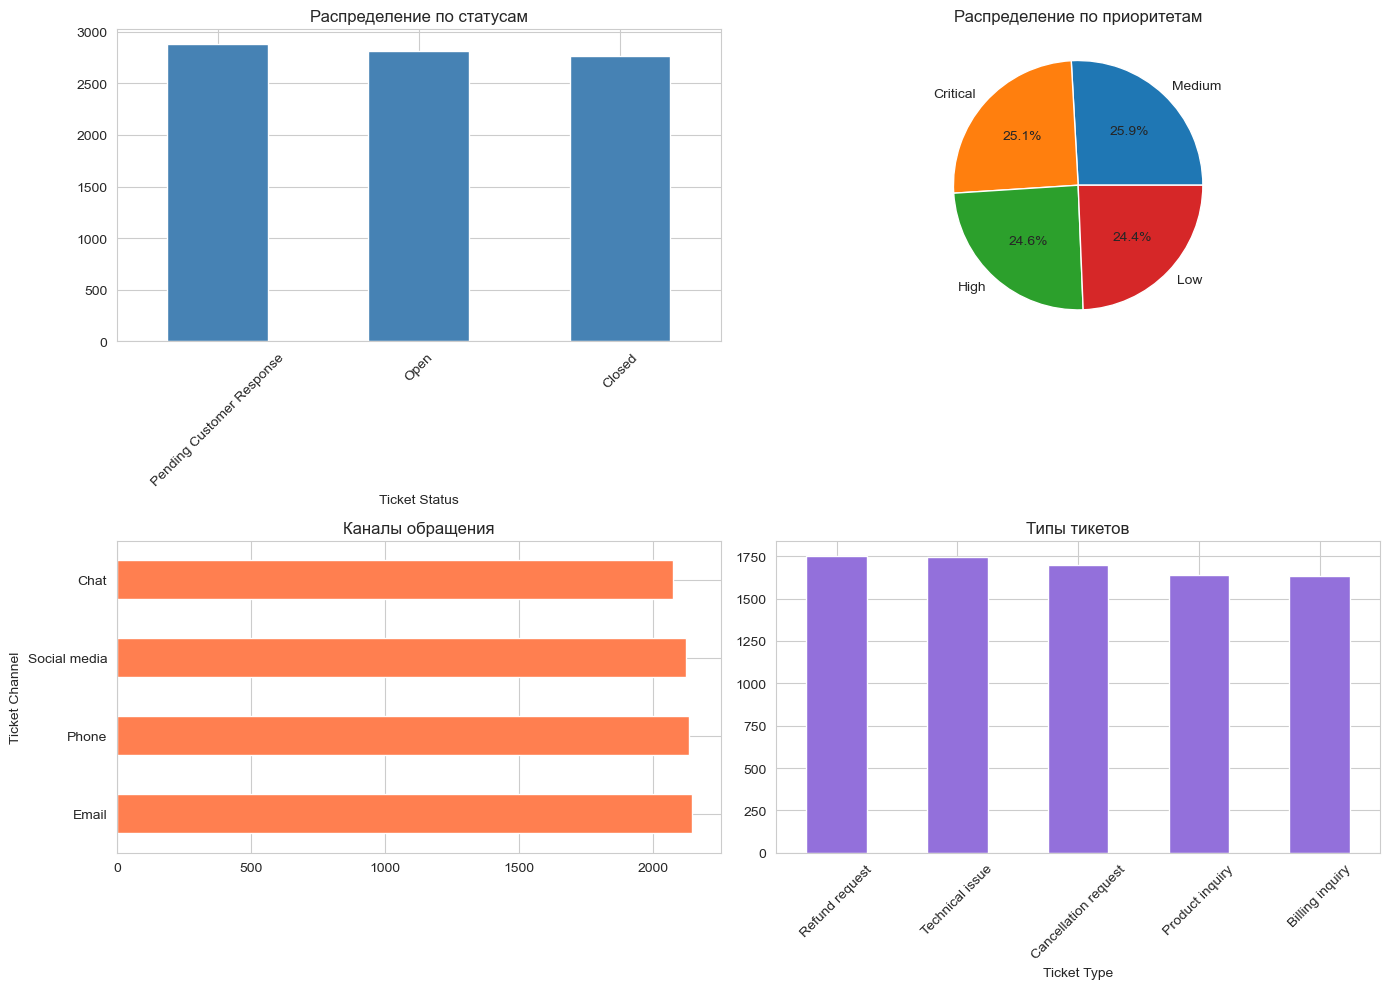


🚨 ВЫВОД ДЛЯ СИСТЕМНОГО АНАЛИТИКА
Открытых/в работе тикетов: 2819 (33.3%)
Закрытых тикетов: 2769 (32.7%)

⚠️  Возможная проблема: 33.3% тикетов висят без решения!


In [12]:
# ============================================
# УГЛУБЛЁННЫЙ АНАЛИЗ: СТАТУСЫ И РАСПРЕДЕЛЕНИЯ
# ============================================

print("=" * 60)
print("📊 РАСПРЕДЕЛЕНИЕ ТИКЕТОВ ПО СТАТУСАМ")
print("=" * 60)
status_counts = df['Ticket Status'].value_counts()
print(status_counts)
print(f"\nПроцентное соотношение:")
print((status_counts / len(df) * 100).round(2))

print("\n" + "=" * 60)
print("🎯 РАСПРЕДЕЛЕНИЕ ПО ПРИОРИТЕТАМ")
print("=" * 60)
print(df['Ticket Priority'].value_counts())

print("\n" + "=" * 60)
print("📞 РАСПРЕДЕЛЕНИЕ ПО КАНАЛАМ ОБРАЩЕНИЯ")
print("=" * 60)
print(df['Ticket Channel'].value_counts())

print("\n" + "=" * 60)
print("📦 ТИПЫ ТИКЕТОВ (Ticket Type)")
print("=" * 60)
print(df['Ticket Type'].value_counts())

print("\n" + "=" * 60)
print("💡 КРОСС-АНАЛИЗ: Статус + Пропуски Resolution")
print("=" * 60)
cross_tab = pd.crosstab(df['Ticket Status'], df['Resolution'].isnull())
cross_tab.columns = ['С решением', 'Без решения']
print(cross_tab)

print("\n" + "=" * 60)
print("📈 ПЕРВЫЕ ГРАФИКИ")
print("=" * 60)

# Графики
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Статусы
status_counts.plot(kind='bar', ax=axes[0, 0], color='steelblue')
axes[0, 0].set_title('Распределение по статусам', fontsize=12)
axes[0, 0].tick_params(axis='x', rotation=45)

# 2. Приоритеты
df['Ticket Priority'].value_counts().plot(kind='pie', ax=axes[0, 1], autopct='%1.1f%%')
axes[0, 1].set_ylabel('')
axes[0, 1].set_title('Распределение по приоритетам', fontsize=12)

# 3. Каналы
df['Ticket Channel'].value_counts().plot(kind='barh', ax=axes[1, 0], color='coral')
axes[1, 0].set_title('Каналы обращения', fontsize=12)

# 4. Типы тикетов
df['Ticket Type'].value_counts().plot(kind='bar', ax=axes[1, 1], color='mediumpurple')
axes[1, 1].set_title('Типы тикетов', fontsize=12)
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# ============================================
# 🎯 ГЛАВНАЯ ГИПОТЕЗА: "Узкое место"
# ============================================
print("\n" + "=" * 60)
print("🚨 ВЫВОД ДЛЯ СИСТЕМНОГО АНАЛИТИКА")
print("=" * 60)
open_tickets = status_counts.get('Open', 0) + status_counts.get('In Progress', 0) + status_counts.get('Pending', 0)
print(f"Открытых/в работе тикетов: {open_tickets} ({(open_tickets/len(df)*100).round(1)}%)")
print(f"Закрытых тикетов: {status_counts.get('Closed', 0)} ({(status_counts.get('Closed', 0)/len(df)*100).round(1)}%)")
print(f"\n⚠️  Возможная проблема: {(open_tickets/len(df)*100).round(1)}% тикетов висят без решения!")

In [13]:
# ============================================
# 🔍 АНАЛИЗ "УЗКИХ МЕСТ" ПО ТИПАМ ТИКЕТОВ
# ============================================

print("=" * 60)
print("🎯 КАКИЕ ТИПЫ ТИКЕТОВ ЧАЩЕ ВСЕГО ЗАСТРЕВАЮТ?")
print("=" * 60)

# Какие типы тикетов чаще всего в статусе "Pending Customer Response"
pending_by_type = df[df['Ticket Status'] == 'Pending Customer Response']['Ticket Type'].value_counts()
print("Тикеты, ожидающие ответа клиента (по типам):")
print(pending_by_type)

print("\n" + "=" * 60)
print("⏰ АНАЛИЗ ВРЕМЕНИ ОТВЕТА И РЕШЕНИЯ")
print("=" * 60)

# Преобразуем время в числовой формат (уберём ' hours', ' minutes' и т.д.)
def parse_time(time_str):
    if pd.isna(time_str):
        return np.nan
    time_str = str(time_str).lower()
    if 'hour' in time_str:
        return float(time_str.replace('hour', '').replace('s', '').strip())
    elif 'minute' in time_str:
        return float(time_str.replace('minute', '').replace('s', '').strip()) / 60
    elif 'day' in time_str:
        return float(time_str.replace('day', '').replace('s', '').strip()) * 24
    else:
        try:
            return float(time_str)
        except:
            return np.nan

df['First Response Time (hours)'] = df['First Response Time'].apply(parse_time)
df['Time to Resolution (hours)'] = df['Time to Resolution'].apply(parse_time)

print(f"Среднее время первого ответа: {df['First Response Time (hours)'].mean():.2f} часов")
print(f"Медианное время первого ответа: {df['First Response Time (hours)'].median():.2f} часов")
print(f"Среднее время решения: {df['Time to Resolution (hours)'].mean():.2f} часов")
print(f"Медианное время решения: {df['Time to Resolution (hours)'].median():.2f} часов")

print("\n" + "=" * 60)
print("📊 ВРЕМЯ ОТВЕТА ПО ПРИОРИТЕТАМ")
print("=" * 60)
priority_response = df.groupby('Ticket Priority')['First Response Time (hours)'].agg(['mean', 'median', 'count'])
print(priority_response.round(2))

print("\n" + "=" * 60)
print("🚨 ВЫВОДЫ ДЛЯ АВТОМАТИЗАЦИИ")
print("=" * 60)
print(f"1. {len(df[df['Ticket Status'] == 'Pending Customer Response'])} тикетов ждут клиента")
print(f"2. Среднее время ответа: {df['First Response Time (hours)'].mean():.1f} часов")
print(f"3. Нужно автоматизировать:")
print("   - Напоминания клиентам через 24/48 часов")
print("   - Авто-закрытие тикетов через 7 дней без ответа")
print("   - Эскалацию по SLA для приоритетов High/Critical")

🎯 КАКИЕ ТИПЫ ТИКЕТОВ ЧАЩЕ ВСЕГО ЗАСТРЕВАЮТ?
Тикеты, ожидающие ответа клиента (по типам):
Ticket Type
Cancellation request    597
Refund request          592
Product inquiry         576
Technical issue         565
Billing inquiry         551
Name: count, dtype: int64

⏰ АНАЛИЗ ВРЕМЕНИ ОТВЕТА И РЕШЕНИЯ
Среднее время первого ответа: nan часов
Медианное время первого ответа: nan часов
Среднее время решения: nan часов
Медианное время решения: nan часов

📊 ВРЕМЯ ОТВЕТА ПО ПРИОРИТЕТАМ
                 mean  median  count
Ticket Priority                     
Critical          NaN     NaN      0
High              NaN     NaN      0
Low               NaN     NaN      0
Medium            NaN     NaN      0

🚨 ВЫВОДЫ ДЛЯ АВТОМАТИЗАЦИИ
1. 2881 тикетов ждут клиента
2. Среднее время ответа: nan часов
3. Нужно автоматизировать:
   - Напоминания клиентам через 24/48 часов
   - Авто-закрытие тикетов через 7 дней без ответа
   - Эскалацию по SLA для приоритетов High/Critical


In [14]:
# Смотрим реальные значения колонок времени
print("=" * 60)
print("🔍 ПРИМЕРЫ ЗНАЧЕНИЙ В КОЛОНКАХ ВРЕМЕНИ")
print("=" * 60)

print("\nFirst Response Time (первые 10 непустых значений):")
print(df['First Response Time'].dropna().head(10).tolist())

print("\nTime to Resolution (первые 10 непустых значений):")
print(df['Time to Resolution'].dropna().head(10).tolist())

print("\n" + "=" * 60)
print("📊 УНИКАЛЬНЫЕ ЗНАЧЕНИЯ (первые 20)")
print("=" * 60)
print("First Response Time:")
print(df['First Response Time'].dropna().unique()[:20])
print("\nTime to Resolution:")
print(df['Time to Resolution'].dropna().unique()[:20])

🔍 ПРИМЕРЫ ЗНАЧЕНИЙ В КОЛОНКАХ ВРЕМЕНИ

First Response Time (первые 10 непустых значений):
['2023-06-01 12:15:36', '2023-06-01 16:45:38', '2023-06-01 11:14:38', '2023-06-01 07:29:40', '2023-06-01 00:12:42', '2023-06-01 10:32:47', '2023-06-01 09:25:48', '2023-06-01 17:46:49', '2023-06-01 12:05:51', '2023-06-01 19:03:53']

Time to Resolution (первые 10 непустых значений):
['2023-06-01 18:05:38', '2023-06-01 01:57:40', '2023-06-01 19:53:42', '2023-05-31 23:51:49', '2023-06-01 09:27:51', '2023-05-31 23:08:55', '2023-06-01 15:58:59', '2023-06-01 20:29:04', '2023-06-01 06:03:17', '2023-06-01 18:23:17']

📊 УНИКАЛЬНЫЕ ЗНАЧЕНИЯ (первые 20)
First Response Time:
['2023-06-01 12:15:36' '2023-06-01 16:45:38' '2023-06-01 11:14:38'
 '2023-06-01 07:29:40' '2023-06-01 00:12:42' '2023-06-01 10:32:47'
 '2023-06-01 09:25:48' '2023-06-01 17:46:49' '2023-06-01 12:05:51'
 '2023-06-01 19:03:53' '2023-06-01 20:34:54' '2023-06-01 06:22:55'
 '2023-06-01 15:09:57' '2023-06-01 19:46:59' '2023-06-01 21:05:01'
 '2023

🔍 ПРЕОБРАЗОВАНИЕ TIMESTAMP'ОВ
Тикетов с данными о времени: 1404

Среднее время от первого ответа до решения: 7.58 часов
Медианное время: 6.34 часов
Минимальное: 0.00 часов
Максимальное: 23.47 часов

📊 ВРЕМЯ РЕШЕНИЯ ПО ПРИОРИТЕТАМ
                 Среднее (часы)  Медиана (часы)  Количество
Ticket Priority                                            
Critical                   7.15            5.98         374
High                       8.07            7.12         355
Low                        7.95            7.08         334
Medium                     7.17            5.87         341

📊 ВРЕМЯ РЕШЕНИЯ ПО ТИПАМ ТИКЕТОВ
                      Среднее (часы)  Медиана (часы)  Количество
Ticket Type                                                     
Refund request                  8.12            6.71         304
Cancellation request            7.69            6.37         265
Product inquiry                 7.68            6.98         257
Technical issue                 7.37            6.3

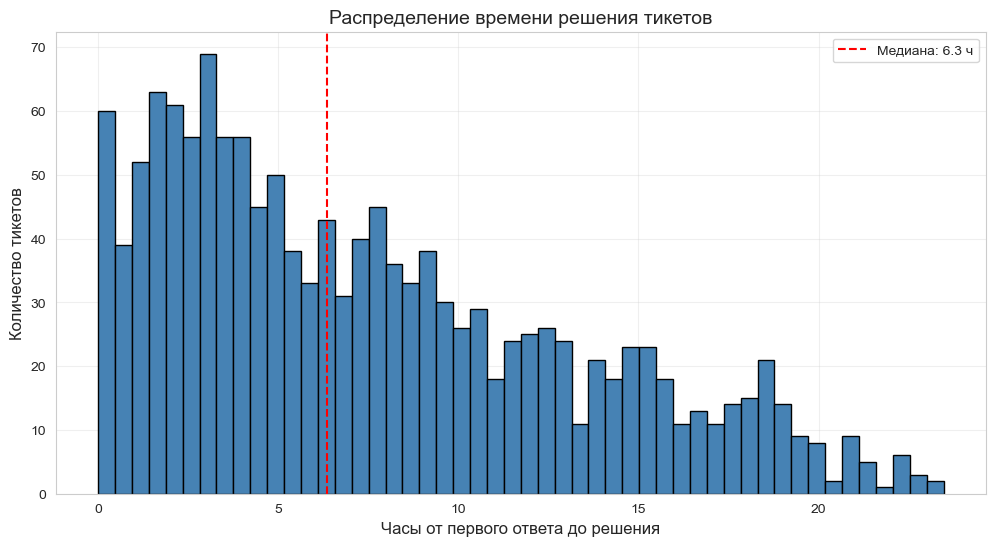


🚨 ИТОГОВЫЕ ВЫВОДЫ ДЛЯ СИСТЕМНОГО АНАЛИТИКА
1. Среднее время решения (после первого ответа): 7.6 часов
2. Медианное время: 6.3 часов
3. Есть тикеты, которые решаются за 23.5 часов!

⚠️  КРИТИЧЕСКАЯ ПРОБЛЕМА:
   - В системе НЕ логируется дата создания тикета
   - Невозможно рассчитать полное время обработки (SLA)
   - Нужно добавить поле 'Created At' в систему


In [15]:
# ============================================
# ⏰ АНАЛИЗ ВРЕМЕНИ: ОТ ПЕРВОГО ОТВЕТА ДО РЕШЕНИЯ
# ============================================

print("=" * 60)
print("🔍 ПРЕОБРАЗОВАНИЕ TIMESTAMP'ОВ")
print("=" * 60)

# Преобразуем строки в datetime
df['First Response Time'] = pd.to_datetime(df['First Response Time'], errors='coerce')
df['Time to Resolution'] = pd.to_datetime(df['Time to Resolution'], errors='coerce')

# Считаем разницу (в часах)
df['Response to Resolution (hours)'] = (
    (df['Time to Resolution'] - df['First Response Time']).dt.total_seconds() / 3600
)

# Убираем отрицательные значения (ошибки данных)
df['Response to Resolution (hours)'] = df['Response to Resolution (hours)'].apply(
    lambda x: x if x >= 0 else np.nan
)

print(f"Тикетов с данными о времени: {df['Response to Resolution (hours)'].notna().sum()}")
print(f"\nСреднее время от первого ответа до решения: {df['Response to Resolution (hours)'].mean():.2f} часов")
print(f"Медианное время: {df['Response to Resolution (hours)'].median():.2f} часов")
print(f"Минимальное: {df['Response to Resolution (hours)'].min():.2f} часов")
print(f"Максимальное: {df['Response to Resolution (hours)'].max():.2f} часов")

print("\n" + "=" * 60)
print("📊 ВРЕМЯ РЕШЕНИЯ ПО ПРИОРИТЕТАМ")
print("=" * 60)
priority_time = df.groupby('Ticket Priority')['Response to Resolution (hours)'].agg(['mean', 'median', 'count'])
priority_time.columns = ['Среднее (часы)', 'Медиана (часы)', 'Количество']
print(priority_time.round(2))

print("\n" + "=" * 60)
print("📊 ВРЕМЯ РЕШЕНИЯ ПО ТИПАМ ТИКЕТОВ")
print("=" * 60)
type_time = df.groupby('Ticket Type')['Response to Resolution (hours)'].agg(['mean', 'median', 'count'])
type_time.columns = ['Среднее (часы)', 'Медиана (часы)', 'Количество']
print(type_time.round(2).sort_values('Среднее (часы)', ascending=False))

print("\n" + "=" * 60)
print("📈 ГИСТОГРАММА ВРЕМЕНИ РЕШЕНИЯ")
print("=" * 60)
plt.figure(figsize=(12, 6))
plt.hist(df['Response to Resolution (hours)'].dropna(), bins=50, color='steelblue', edgecolor='black')
plt.xlabel('Часы от первого ответа до решения', fontsize=12)
plt.ylabel('Количество тикетов', fontsize=12)
plt.title('Распределение времени решения тикетов', fontsize=14)
plt.axvline(df['Response to Resolution (hours)'].median(), color='red', linestyle='--',
            label=f'Медиана: {df["Response to Resolution (hours)"].median():.1f} ч')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("\n" + "=" * 60)
print("🚨 ИТОГОВЫЕ ВЫВОДЫ ДЛЯ СИСТЕМНОГО АНАЛИТИКА")
print("=" * 60)
print(f"1. Среднее время решения (после первого ответа): {df['Response to Resolution (hours)'].mean():.1f} часов")
print(f"2. Медианное время: {df['Response to Resolution (hours)'].median():.1f} часов")
print(f"3. Есть тикеты, которые решаются за {df['Response to Resolution (hours)'].max():.1f} часов!")
print(f"\n⚠️  КРИТИЧЕСКАЯ ПРОБЛЕМА:")
print(f"   - В системе НЕ логируется дата создания тикета")
print(f"   - Невозможно рассчитать полное время обработки (SLA)")
print(f"   - Нужно добавить поле 'Created At' в систему")
